# CloudTrail Robust Feature Engineering, Full Classifier Benchmark, and Multi-Model Optuna

This notebook replaces the earlier single-winner workflow with a leakage-aware, temporally valid ML architecture.

1. Deterministic deduplication and corrected write-event semantics.
2. Actor × 5-minute windows with strictly prior historical predictors.
3. Separate current-detection, future-30-minute, and combined weak-label targets.
4. Censoring only where the complete global future horizon is unavailable.
5. Chronological train/validation/test periods with embargo.
6. The full requested sklearn/LazyPredict-style classifier catalog.
7. Explicit XGBoost, LightGBM, CatBoost, Balanced Random Forest, Easy Ensemble, and MLP benchmarking.
8. Expanding temporal folds, average precision, worst-fold performance, alert-budget recall, calibration, Optuna, untouched-test evaluation, robustness slices, and exports.

> **Research caveat:** these targets are weak policy proxies, not analyst-confirmed ground truth. Replace or augment them with reviewed incidents before production use.

## 0. Environment and configuration
Run from the project directory that contains `cloudtrail_eda_workspace/parquet_events_full`. Missing libraries are installed into the active kernel.

In [1]:
import importlib.util, inspect, json, math, platform, random, subprocess, sys, time, warnings
from dataclasses import asdict, dataclass
from hashlib import sha256
from pathlib import Path

REQUIRED_PACKAGES={'duckdb':'duckdb','joblib':'joblib','lazypredict':'lazypredict','optuna':'optuna','imbalanced-learn':'imblearn','xgboost':'xgboost','lightgbm':'lightgbm','catboost':'catboost'}
missing_packages=[pkg for pkg,module in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module) is None]
if missing_packages:
    print('Installing missing packages:',missing_packages)
    subprocess.check_call([sys.executable,'-m','pip','install',*missing_packages])

import cloudpickle, duckdb, joblib, lazypredict, matplotlib.pyplot as plt, numpy as np, optuna, pandas as pd, sklearn
from catboost import CatBoostClassifier
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
from lightgbm import LGBMClassifier
from scipy.special import expit
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV, PassiveAggressiveClassifier, Perceptron, RidgeClassifier, RidgeClassifierCV, SGDClassifier
from sklearn.metrics import average_precision_score, balanced_accuracy_score, brier_score_loss, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score
from sklearn.naive_bayes import BernoulliNB, GaussianNB
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
from sklearn.svm import LinearSVC, NuSVC, SVC
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight
try:
    from sklearn.utils._testing import CheckingClassifier
except Exception:
    CheckingClassifier=None
warnings.filterwarnings('ignore',category=FutureWarning); warnings.filterwarnings('ignore',category=UserWarning)
SEED=540; random.seed(SEED); np.random.seed(SEED)

@dataclass(frozen=True)
class Config:
    workspace: Path=Path.cwd()/'cloudtrail_eda_workspace'
    window_minutes: int=5
    target_horizon_minutes: int=30
    target_mode: str='forecast_30m'  # detection_current | forecast_30m | current_or_future_30m
    behavior_only: bool=True
    train_end: str='2019-07-01T00:00:00Z'
    valid_end: str='2020-01-01T00:00:00Z'
    embargo_days: int=2
    screen_max_rows: int=30000
    screen_negative_ratio: int=40
    quadratic_model_max_rows: int=8000
    kernel_model_max_rows: int=15000
    temporal_folds: int=3
    advanced_alert_budget_per_day: float=5.0
    operating_alert_budget_per_day: float=5.0
    optuna_trials_boosting: int=60
    optuna_trials_other: int=40
    optuna_timeout_per_model_seconds: int=1800
    tune_top_extra_candidates: int=2
    enable_native_lazypredict_diagnostic: bool=False
    enable_optuna: bool=True
    enable_calibration: bool=True
    bootstrap_iterations: int=500
    permutation_max_rows: int=20000
CFG=Config(); WORKSPACE=CFG.workspace; PARQUET_GLOB=WORKSPACE/'parquet_events_full'/'part-*.parquet'; OUTPUT_DIR=WORKSPACE/'robust_ml_outputs'; OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
FEATURE_PARQUET=OUTPUT_DIR/'cloudtrail_actor_window_features_corrected.parquet'
TRAIN_END=pd.Timestamp(CFG.train_end); VALID_END=pd.Timestamp(CFG.valid_end)
if TRAIN_END.tzinfo is None: TRAIN_END=TRAIN_END.tz_localize('UTC')
if VALID_END.tzinfo is None: VALID_END=VALID_END.tz_localize('UTC')
print(json.dumps({**asdict(CFG),'workspace':str(WORKSPACE),'feature_parquet':str(FEATURE_PARQUET)},default=str,indent=2))
print({'python':platform.python_version(),'sklearn':sklearn.__version__,'duckdb':duckdb.__version__,'lazypredict':getattr(lazypredict,'__version__','unknown'),'optuna':optuna.__version__})

Installing missing packages: ['lightgbm', 'catboost']
{
  "workspace": "E:\\Trash\\MLOPS\\cloudtrail_eda_workspace",
  "window_minutes": 5,
  "target_horizon_minutes": 30,
  "target_mode": "forecast_30m",
  "behavior_only": true,
  "train_end": "2019-07-01T00:00:00Z",
  "valid_end": "2020-01-01T00:00:00Z",
  "embargo_days": 2,
  "screen_max_rows": 30000,
  "screen_negative_ratio": 40,
  "quadratic_model_max_rows": 8000,
  "kernel_model_max_rows": 15000,
  "temporal_folds": 3,
  "advanced_alert_budget_per_day": 5.0,
  "operating_alert_budget_per_day": 5.0,
  "optuna_trials_boosting": 60,
  "optuna_trials_other": 40,
  "optuna_timeout_per_model_seconds": 1800,
  "tune_top_extra_candidates": 2,
  "enable_native_lazypredict_diagnostic": false,
  "enable_optuna": true,
  "enable_calibration": true,
  "bootstrap_iterations": 500,
  "permutation_max_rows": 20000,
  "feature_parquet": "E:\\Trash\\MLOPS\\cloudtrail_eda_workspace\\robust_ml_outputs\\cloudtrail_actor_window_features_corrected.par

E:\Anaconda\envs\cloudtrail\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Read normalized Parquet through in-memory DuckDB
This avoids file-lock conflicts with the EDA notebook. DuckDB scans Parquet lazily.

In [2]:
parquet_files=sorted((WORKSPACE/'parquet_events_full').glob('part-*.parquet'))
if not parquet_files: raise FileNotFoundError(f'No normalized Parquet parts found at {PARQUET_GLOB}. Run the EDA notebook first.')
con=duckdb.connect(database=':memory:')
parquet_sql=str(PARQUET_GLOB).replace('\\','/').replace("'","''")
con.execute(f"CREATE OR REPLACE VIEW events AS SELECT * FROM read_parquet('{parquet_sql}', union_by_name=true)")
REQUIRED_COLUMNS={'source_file','source_record_index','event_time','event_source','event_name','aws_region','source_ip','user_agent','error_code','error_message','request_id','event_id','management_event','read_only','identity_type','actor_id','mfa_authenticated','request_parameters_json'}
available={r[0] for r in con.execute('DESCRIBE SELECT * FROM events').fetchall()}; missing=sorted(REQUIRED_COLUMNS-available)
if missing: raise KeyError(f'Normalized events schema is missing: {missing}')
EVENT_AUDIT=con.execute('SELECT COUNT(*) AS raw_rows, COUNT(DISTINCT event_id) FILTER (WHERE event_id IS NOT NULL) AS distinct_nonnull_event_ids, MIN(event_time) AS min_event_time, MAX(event_time) AS max_event_time FROM events').fetchdf()
display(EVENT_AUDIT)

,raw_rows,distinct_nonnull_event_ids,min_event_time,max_event_time
0,1939207,1225784,2017-02-13 01:27:06+05:30,2020-10-08 02:33:30+05:30


## 2. Deduplication and corrected event semantics
When `read_only` is unknown, the action taxonomy is used. Missing values are never automatically interpreted as writes.

In [3]:
con.execute('''
CREATE OR REPLACE TABLE events_dedup AS
SELECT * EXCLUDE (_dedup_key,_rn) FROM (
 SELECT *, COALESCE(NULLIF(TRIM(CAST(event_id AS VARCHAR)),''),CONCAT('__NULL__|',CAST(source_file AS VARCHAR),'|',CAST(source_record_index AS VARCHAR))) AS _dedup_key,
 ROW_NUMBER() OVER (PARTITION BY COALESCE(NULLIF(TRIM(CAST(event_id AS VARCHAR)),''),CONCAT('__NULL__|',CAST(source_file AS VARCHAR),'|',CAST(source_record_index AS VARCHAR))) ORDER BY event_time,source_file,source_record_index) AS _rn
 FROM events
) x WHERE _rn=1
''')
con.execute('''
CREATE OR REPLACE TABLE event_semantic AS
WITH base AS (
 SELECT *, COALESCE(NULLIF(TRIM(CAST(actor_id AS VARCHAR)),''),'<unknown_actor>') AS actor_key,
 CASE WHEN LOWER(COALESCE(user_agent,'')) LIKE '%console%' THEN 'console' WHEN LOWER(COALESCE(user_agent,'')) LIKE '%aws-cli%' THEN 'cli'
      WHEN LOWER(COALESCE(user_agent,'')) LIKE '%boto%' OR LOWER(COALESCE(user_agent,'')) LIKE '%botocore%' THEN 'python_sdk'
      WHEN LOWER(COALESCE(user_agent,'')) LIKE '%terraform%' THEN 'terraform' WHEN LOWER(COALESCE(user_agent,'')) LIKE '%cloudformation%' THEN 'cloudformation'
      WHEN LOWER(COALESCE(user_agent,'')) LIKE '%java%' THEN 'java_sdk' WHEN NULLIF(TRIM(COALESCE(user_agent,'')),'') IS NULL THEN 'missing' ELSE 'other' END AS ua_family,
 CASE WHEN LOWER(COALESCE(event_name,'')) SIMILAR TO '(get|list|describe|lookup|head|download|select)%' THEN 'read'
      WHEN LOWER(COALESCE(event_name,'')) SIMILAR TO '(create|put|update|modify|attach|associate|enable|start|run|invoke|upload)%' THEN 'change'
      WHEN LOWER(COALESCE(event_name,'')) SIMILAR TO '(delete|remove|detach|disable|stop|terminate|revoke)%' THEN 'destructive'
      WHEN LOWER(COALESCE(event_name,'')) LIKE '%login%' OR LOWER(COALESCE(event_name,'')) LIKE '%authenticate%' THEN 'authentication' ELSE 'other' END AS action_family,
 CASE WHEN NULLIF(TRIM(COALESCE(error_code,'')),'') IS NULL THEN 'none' WHEN LOWER(error_code) LIKE '%accessdenied%' OR LOWER(error_code) LIKE '%unauthorized%' THEN 'authorization'
      WHEN LOWER(error_code) LIKE '%throttl%' THEN 'throttling' WHEN LOWER(error_code) LIKE '%notfound%' OR LOWER(error_code) LIKE '%nosuch%' THEN 'not_found' ELSE 'other' END AS error_family
 FROM events_dedup
), flags AS (
 SELECT *, CASE WHEN read_only IS NOT NULL THEN CAST(read_only=FALSE AS INTEGER) WHEN action_family IN ('change','destructive','authentication') THEN 1 ELSE 0 END AS is_write_event,
 CAST(read_only IS NOT NULL AS INTEGER) AS read_only_known, CAST(COALESCE(identity_type,'')='Root' AS INTEGER) AS is_root,
 CAST(COALESCE(identity_type,'')='Root' AND COALESCE(mfa_authenticated,FALSE)=FALSE AS INTEGER) AS is_root_no_mfa,
 CAST(error_family='authorization' AS INTEGER) AS is_auth_error,
 CAST(event_name IN ('StopLogging','DeleteTrail','UpdateTrail','PutEventSelectors','DeleteEventDataStore') AS INTEGER) AS flag_audit_tamper,
 CAST(event_name IN ('PutBucketPolicy','PutBucketAcl','DeletePublicAccessBlock','PutBucketPublicAccessBlock','PutAccountPublicAccessBlock') AS INTEGER) AS flag_public_exposure,
 CAST(event_name IN ('CreateAccessKey','AttachUserPolicy','AttachRolePolicy','PutUserPolicy','PutRolePolicy','CreatePolicyVersion','SetDefaultPolicyVersion') AS INTEGER) AS flag_credential_or_privilege,
 CAST(event_name='ConsoleLogin' AND COALESCE(mfa_authenticated,FALSE)=FALSE AS INTEGER) AS flag_console_no_mfa
 FROM base
)
SELECT *, CAST(flag_audit_tamper+flag_public_exposure+flag_credential_or_privilege+flag_console_no_mfa>0 AS INTEGER) AS label_signal_current,
CASE WHEN flag_audit_tamper=1 THEN 'audit_tamper' WHEN flag_public_exposure=1 THEN 'public_exposure' WHEN flag_credential_or_privilege=1 THEN 'credential_or_privilege'
     WHEN flag_console_no_mfa=1 THEN 'console_no_mfa' ELSE 'none' END AS policy_signal_category
FROM flags
''')
con.execute('''
CREATE OR REPLACE TABLE event_causal AS
SELECT *,
 COUNT(*) OVER (PARTITION BY actor_key ORDER BY event_time,source_file,source_record_index ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING) AS actor_prior_events,
 COUNT(*) OVER (PARTITION BY actor_key,event_source,event_name ORDER BY event_time,source_file,source_record_index ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING) AS actor_api_prior_events,
 COUNT(*) OVER (PARTITION BY event_source,event_name ORDER BY event_time,source_file,source_record_index ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING) AS global_api_prior_events,
 COUNT(*) OVER (PARTITION BY actor_key,COALESCE(source_ip,'<missing>') ORDER BY event_time,source_file,source_record_index ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING) AS actor_ip_prior_events,
 COUNT(*) OVER (PARTITION BY actor_key,ua_family ORDER BY event_time,source_file,source_record_index ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING) AS actor_ua_prior_events
FROM event_semantic
''')
DEDUP_AUDIT=con.execute('SELECT (SELECT COUNT(*) FROM events) AS raw_rows,(SELECT COUNT(*) FROM events_dedup) AS deduplicated_rows,(SELECT COUNT(*) FROM events)-(SELECT COUNT(*) FROM events_dedup) AS removed_rows,(SELECT SUM(is_write_event) FROM event_semantic) AS corrected_write_events,(SELECT SUM(read_only_known) FROM event_semantic) AS rows_with_known_read_only').fetchdf(); display(DEDUP_AUDIT)

,raw_rows,deduplicated_rows,removed_rows,corrected_write_events,rows_with_known_read_only
0,1939207,1225784,713423,1641.0,50919.0


## 3. Actor-window features and corrected targets
The future target is zero when no signal occurs in the next 30 minutes. Only the final global 30-minute tail is censored.

In [4]:
WINDOW_MINUTES=int(CFG.window_minutes); HORIZON_MINUTES=int(CFG.target_horizon_minutes)
con.execute(f'''
CREATE OR REPLACE TABLE actor_windows AS
SELECT actor_key AS actor_id,time_bucket(INTERVAL '{WINDOW_MINUTES} minutes',event_time) AS window_start,COUNT(*) AS event_count,
 COUNT(DISTINCT event_source) AS distinct_services,COUNT(DISTINCT event_name) AS distinct_apis,COUNT(DISTINCT aws_region) AS distinct_regions,
 COUNT(DISTINCT source_ip) AS distinct_source_ips,COUNT(DISTINCT ua_family) AS distinct_ua_families,SUM(CAST(error_family<>'none' AS INTEGER)) AS error_count,
 SUM(is_auth_error) AS auth_error_count,SUM(is_write_event) AS write_count,SUM(read_only_known) AS read_only_known_count,
 SUM(CAST(COALESCE(management_event,FALSE) AS INTEGER)) AS management_count,SUM(CAST(COALESCE(read_only,FALSE) AS INTEGER)) AS readonly_count,
 SUM(CAST(action_family='destructive' AS INTEGER)) AS destructive_count,SUM(CAST(action_family='authentication' AS INTEGER)) AS authentication_count,
 SUM(CAST(EXTRACT(hour FROM event_time) NOT BETWEEN 7 AND 19 AS INTEGER)) AS off_hours_count,SUM(CAST(EXTRACT(isodow FROM event_time) IN (6,7) AS INTEGER)) AS weekend_count,
 SUM(CAST(actor_prior_events=0 AS INTEGER)) AS first_actor_event_count,SUM(CAST(actor_api_prior_events=0 AS INTEGER)) AS new_actor_api_count,
 SUM(CAST(actor_ip_prior_events=0 AS INTEGER)) AS new_actor_ip_count,SUM(CAST(actor_ua_prior_events=0 AS INTEGER)) AS new_actor_ua_count,
 SUM(CAST(global_api_prior_events<20 AS INTEGER)) AS globally_rare_api_count,AVG(LN(1+actor_prior_events)) AS mean_log_actor_prior,
 AVG(LN(1+actor_api_prior_events)) AS mean_log_actor_api_prior,arg_max(event_source,event_time) AS last_service,arg_max(aws_region,event_time) AS last_region,
 arg_max(ua_family,event_time) AS last_ua_family,SUM(is_root) AS root_event_count_current,SUM(is_root_no_mfa) AS root_no_mfa_count_current,
 SUM(flag_audit_tamper) AS audit_tamper_count_current,SUM(flag_public_exposure) AS public_exposure_count_current,
 SUM(flag_credential_or_privilege) AS credential_privilege_count_current,SUM(flag_console_no_mfa) AS console_no_mfa_count_current,
 MAX(label_signal_current) AS label_signal_current,arg_max(policy_signal_category,event_time) FILTER (WHERE label_signal_current=1) AS policy_signal_category_current
FROM event_causal GROUP BY actor_key,time_bucket(INTERVAL '{WINDOW_MINUTES} minutes',event_time)
''')
con.execute(f'''
CREATE OR REPLACE TABLE ml_feature_windows AS
WITH history AS (
 SELECT *,SUM(event_count) OVER w1h AS prior_events_1h,SUM(event_count) OVER w24h AS prior_events_24h,SUM(event_count) OVER w7d AS prior_events_7d,
 SUM(error_count) OVER w24h AS prior_errors_24h,SUM(auth_error_count) OVER w24h AS prior_auth_errors_24h,SUM(write_count) OVER w24h AS prior_writes_24h,
 SUM(new_actor_api_count) OVER w7d AS prior_new_apis_7d,SUM(distinct_source_ips) OVER w24h AS prior_ip_mass_24h,AVG(event_count) OVER w7d AS prior_mean_events_per_window_7d,
 COUNT(*) OVER w24h AS prior_active_windows_24h,COUNT(*) OVER w7d AS prior_active_windows_7d,
 MAX(label_signal_current) OVER (PARTITION BY actor_id ORDER BY window_start RANGE BETWEEN INTERVAL '1 microsecond' FOLLOWING AND INTERVAL '{HORIZON_MINUTES} minutes' FOLLOWING) AS future_signal_raw,
 MAX(window_start) OVER () AS global_max_window
 FROM actor_windows
 WINDOW w1h AS (PARTITION BY actor_id ORDER BY window_start RANGE BETWEEN INTERVAL '1 hour' PRECEDING AND INTERVAL '1 microsecond' PRECEDING),
 w24h AS (PARTITION BY actor_id ORDER BY window_start RANGE BETWEEN INTERVAL '24 hours' PRECEDING AND INTERVAL '1 microsecond' PRECEDING),
 w7d AS (PARTITION BY actor_id ORDER BY window_start RANGE BETWEEN INTERVAL '7 days' PRECEDING AND INTERVAL '1 microsecond' PRECEDING)
)
SELECT * EXCLUDE (future_signal_raw,global_max_window),label_signal_current AS target_detection_current,
 CASE WHEN window_start>global_max_window-INTERVAL '{HORIZON_MINUTES} minutes' THEN NULL ELSE COALESCE(future_signal_raw,0) END AS target_forecast_30m,
 CASE WHEN window_start>global_max_window-INTERVAL '{HORIZON_MINUTES} minutes' THEN NULL ELSE GREATEST(label_signal_current,COALESCE(future_signal_raw,0)) END AS target_current_or_future_30m,
 COALESCE(event_count/NULLIF(prior_mean_events_per_window_7d,0),0.0) AS event_burst_vs_7d,COALESCE(error_count::DOUBLE/NULLIF(event_count,0),0.0) AS error_rate_current,
 COALESCE(write_count::DOUBLE/NULLIF(event_count,0),0.0) AS write_rate_current,COALESCE(read_only_known_count::DOUBLE/NULLIF(event_count,0),0.0) AS read_only_coverage_current,
 COALESCE(new_actor_api_count::DOUBLE/NULLIF(event_count,0),0.0) AS new_api_rate_current,COALESCE(new_actor_ip_count::DOUBLE/NULLIF(event_count,0),0.0) AS new_ip_rate_current,
 SIN(2*PI()*EXTRACT(hour FROM window_start)/24.0) AS hour_sin,COS(2*PI()*EXTRACT(hour FROM window_start)/24.0) AS hour_cos,
 SIN(2*PI()*EXTRACT(isodow FROM window_start)/7.0) AS dow_sin,COS(2*PI()*EXTRACT(isodow FROM window_start)/7.0) AS dow_cos,
 CAST(window_start>=TIMESTAMPTZ '2019-08-01 00:00:00+00' AND window_start<TIMESTAMPTZ '2019-09-01 00:00:00+00' AS INTEGER) AS is_aug2019_stress
FROM history
''')
FEATURE_AUDIT=con.execute('''SELECT COUNT(*) AS total_windows,COUNT(DISTINCT actor_id) AS actors,MIN(window_start) AS min_time,MAX(window_start) AS max_time,
SUM(target_detection_current) AS detection_positives,SUM(target_forecast_30m) AS forecast_positives,SUM(target_current_or_future_30m) AS combined_positives,
COUNT(*)-COUNT(target_forecast_30m) AS globally_censored_tail_windows,
COUNT(*) FILTER (WHERE target_forecast_30m IS NULL AND window_start<=(SELECT MAX(window_start) FROM ml_feature_windows)-INTERVAL '30 minutes') AS incorrectly_censored_windows FROM ml_feature_windows''').fetchdf(); display(FEATURE_AUDIT)
if int(FEATURE_AUDIT.loc[0,'incorrectly_censored_windows'])!=0: raise AssertionError('Target censoring audit failed.')
duplicate_keys=con.execute('SELECT COUNT(*) FROM (SELECT actor_id,window_start,COUNT(*) n FROM ml_feature_windows GROUP BY actor_id,window_start HAVING COUNT(*)>1)').fetchone()[0]
if duplicate_keys: raise AssertionError(f'Found {duplicate_keys} duplicate actor-window keys.')
FEATURE_PARQUET.unlink(missing_ok=True); feature_path_sql=FEATURE_PARQUET.resolve().as_posix().replace("'","''")
con.execute(f"COPY (SELECT * FROM ml_feature_windows ORDER BY window_start,actor_id) TO '{feature_path_sql}' (FORMAT PARQUET,COMPRESSION ZSTD)")
print('Exported corrected feature mart:',FEATURE_PARQUET)

,total_windows,actors,min_time,max_time,detection_positives,forecast_positives,combined_positives,globally_censored_tail_windows,incorrectly_censored_windows
0,75609,185,2017-02-13 01:25:00+05:30,2020-10-08 02:30:00+05:30,233.0,197.0,393.0,7,0


Exported corrected feature mart: E:\Trash\MLOPS\cloudtrail_eda_workspace\robust_ml_outputs\cloudtrail_actor_window_features_corrected.parquet


## 4. Feature policy and chronological splits
Set `target_mode` to run detection and forecasting as separate experiments. Policy fields never enter behavior-only predictors.

In [5]:
TARGET_MAP={'detection_current':'target_detection_current','forecast_30m':'target_forecast_30m','current_or_future_30m':'target_current_or_future_30m'}
if CFG.target_mode not in TARGET_MAP: raise ValueError(f'target_mode must be one of {sorted(TARGET_MAP)}')
TARGET_COLUMN=TARGET_MAP[CFG.target_mode]
BEHAVIOR_NUMERIC=['event_count','distinct_services','distinct_apis','distinct_regions','distinct_source_ips','distinct_ua_families','error_count','auth_error_count','write_count','read_only_known_count','read_only_coverage_current','management_count','readonly_count','destructive_count','authentication_count','off_hours_count','weekend_count','first_actor_event_count','new_actor_api_count','new_actor_ip_count','new_actor_ua_count','globally_rare_api_count','mean_log_actor_prior','mean_log_actor_api_prior','prior_events_1h','prior_events_24h','prior_events_7d','prior_errors_24h','prior_auth_errors_24h','prior_writes_24h','prior_new_apis_7d','prior_ip_mass_24h','prior_mean_events_per_window_7d','prior_active_windows_24h','prior_active_windows_7d','event_burst_vs_7d','error_rate_current','write_rate_current','new_api_rate_current','new_ip_rate_current','hour_sin','hour_cos','dow_sin','dow_cos']
BEHAVIOR_CATEGORICAL=['last_service','last_region','last_ua_family']
POLICY_AWARE_EXTRA=['root_event_count_current','root_no_mfa_count_current','audit_tamper_count_current','public_exposure_count_current','credential_privilege_count_current','console_no_mfa_count_current']
FEATURE_COLUMNS=BEHAVIOR_NUMERIC+BEHAVIOR_CATEGORICAL+([] if CFG.behavior_only else POLICY_AWARE_EXTRA)
META_COLUMNS=list(dict.fromkeys(['actor_id','window_start','is_aug2019_stress','label_signal_current','policy_signal_category_current','event_count','first_actor_event_count','audit_tamper_count_current','public_exposure_count_current','credential_privilege_count_current','console_no_mfa_count_current']))
FORBIDDEN_EXACT={'actor_id','window_start','event_id','request_id','source_file','source_record_index','event_name','source_ip','user_agent','label_signal_current','target_detection_current','target_forecast_30m','target_current_or_future_30m','request_parameters_json','response_elements_json','error_message'}
FORBIDDEN_PREFIXES=('target_','label_','future_','flag_','weak_risk','watchlist')
violations=sorted({c for c in FEATURE_COLUMNS if c.lower() in FORBIDDEN_EXACT or any(c.lower().startswith(p) for p in FORBIDDEN_PREFIXES)})
if CFG.behavior_only: violations=sorted(set(violations)|(set(FEATURE_COLUMNS)&set(POLICY_AWARE_EXTRA)))
if violations: raise AssertionError(f'Leakage/policy audit failed: {violations}')
available={r[0] for r in con.execute('DESCRIBE ml_feature_windows').fetchall()}; missing=sorted(set(FEATURE_COLUMNS+META_COLUMNS+[TARGET_COLUMN])-available)
if missing: raise KeyError(f'Missing engineered fields: {missing}')
select_columns=list(dict.fromkeys(META_COLUMNS+[TARGET_COLUMN]+FEATURE_COLUMNS)); quoted=','.join('"'+c.replace('"','""')+'"' for c in select_columns)
model_frame=con.execute(f'SELECT {quoted} FROM ml_feature_windows WHERE "{TARGET_COLUMN}" IS NOT NULL ORDER BY window_start,actor_id').fetchdf()
model_frame['window_start']=pd.to_datetime(model_frame.window_start,utc=True); model_frame[TARGET_COLUMN]=model_frame[TARGET_COLUMN].astype('int8')
embargo=pd.Timedelta(days=CFG.embargo_days); m_train=model_frame.window_start<TRAIN_END-embargo; m_valid=(model_frame.window_start>=TRAIN_END+embargo)&(model_frame.window_start<VALID_END-embargo); m_test=model_frame.window_start>=VALID_END+embargo; m_embargo=~(m_train|m_valid|m_test)
SPLITS={'train':model_frame.loc[m_train].copy().reset_index(drop=True),'validation':model_frame.loc[m_valid].copy().reset_index(drop=True),'test':model_frame.loc[m_test].copy().reset_index(drop=True)}
split_rows=[]
for split_name,frame in SPLITS.items():
    if frame.empty or frame[TARGET_COLUMN].nunique()<2: raise ValueError(f'{split_name} is empty or single-class.')
    split_rows.append({'split':split_name,'rows':len(frame),'start':frame.window_start.min(),'end':frame.window_start.max(),'positives':int(frame[TARGET_COLUMN].sum()),'prevalence':float(frame[TARGET_COLUMN].mean()),'actors':int(frame.actor_id.nunique())})
SPLIT_AUDIT=pd.DataFrame(split_rows); display(SPLIT_AUDIT); print('Embargo rows dropped:',int(m_embargo.sum()),'| target:',TARGET_COLUMN,'| features:',len(FEATURE_COLUMNS))
X_train,y_train=SPLITS['train'][FEATURE_COLUMNS],SPLITS['train'][TARGET_COLUMN]; X_valid,y_valid=SPLITS['validation'][FEATURE_COLUMNS],SPLITS['validation'][TARGET_COLUMN]; X_test,y_test=SPLITS['test'][FEATURE_COLUMNS],SPLITS['test'][TARGET_COLUMN]

,split,rows,start,end,positives,prevalence,actors
0,train,44957,2017-02-12 19:55:00+00:00,2019-06-28 23:25:00+00:00,152,0.003381,106
1,validation,12434,2019-07-03 00:25:00+00:00,2019-12-29 23:45:00+00:00,17,0.001367,19
2,test,17827,2020-01-03 00:35:00+00:00,2020-10-07 20:30:00+00:00,28,0.001571,81


Embargo rows dropped: 384 | target: target_forecast_30m | features: 47


## 5. Preprocessing, temporal folds, and operational metrics
All preprocessing is fitted only on the applicable training period. No random train/test split or global SMOTE is used.

In [6]:
def one_hot_encoder():
    try: return OneHotEncoder(handle_unknown='ignore',min_frequency=5,sparse_output=False)
    except TypeError: return OneHotEncoder(handle_unknown='ignore',min_frequency=5,sparse=False)
def make_preprocessor():
    numeric_columns=BEHAVIOR_NUMERIC+([] if CFG.behavior_only else POLICY_AWARE_EXTRA)
    return ColumnTransformer([('num',Pipeline([('imputer',SimpleImputer(strategy='median',add_indicator=True)),('variance',VarianceThreshold()),('scaler',StandardScaler())]),numeric_columns),('cat',Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('onehot',one_hot_encoder())]),BEHAVIOR_CATEGORICAL)],remainder='drop',sparse_threshold=0)
def score_vector(model,X):
    if hasattr(model,'predict_proba'):
        p=np.asarray(model.predict_proba(X)); return (p[:,1] if p.ndim==2 and p.shape[1]>=2 else p.ravel()).astype(float)
    if hasattr(model,'decision_function'): return expit(np.asarray(model.decision_function(X)).ravel()).astype(float)
    return np.asarray(model.predict(X),dtype=float).ravel()
def fit_with_optional_weights(model,X,y):
    if 'sample_weight' in inspect.signature(model.fit).parameters:
        try: return model.fit(X,y,sample_weight=compute_sample_weight('balanced',y))
        except Exception: pass
    return model.fit(X,y)
def safe_metrics(y,scores,threshold=.5):
    y=np.asarray(y,dtype=int); scores=np.asarray(scores,dtype=float); pred=(scores>=threshold).astype('int8')
    return {'average_precision':float(average_precision_score(y,scores)),'roc_auc':float(roc_auc_score(y,scores)) if np.unique(y).size==2 else np.nan,'balanced_accuracy':float(balanced_accuracy_score(y,pred)),'precision':float(precision_score(y,pred,zero_division=0)),'recall':float(recall_score(y,pred,zero_division=0)),'f1':float(f1_score(y,pred,zero_division=0)),'brier':float(brier_score_loss(y,np.clip(scores,0,1)))}
def days_covered(times):
    t=pd.to_datetime(times,utc=True); return max(1.0,(t.max()-t.min()).total_seconds()/86400+1)
def threshold_for_alert_budget(scores,times,alerts_per_day):
    scores=np.asarray(scores,dtype=float); capacity=max(1,min(len(scores),int(math.floor(days_covered(times)*float(alerts_per_day))))); order=np.argsort(-scores,kind='mergesort'); return float(scores[order[capacity-1]]),capacity
def budget_metrics(y,scores,times,alerts_per_day):
    threshold,capacity=threshold_for_alert_budget(scores,times,alerts_per_day); pred=(np.asarray(scores)>=threshold).astype('int8')
    return {'alert_budget_per_day':float(alerts_per_day),'threshold':threshold,'capacity_rows':capacity,'alerts':int(pred.sum()),'precision':float(precision_score(y,pred,zero_division=0)),'recall':float(recall_score(y,pred,zero_division=0)),'f1':float(f1_score(y,pred,zero_division=0))}
def top_fraction_metrics(y,scores,fraction):
    y=np.asarray(y,dtype=int); k=max(1,int(math.ceil(len(y)*fraction))); idx=np.argsort(-np.asarray(scores))[:k]; tp=int(y[idx].sum()); return {'fraction':fraction,'k':k,'precision_at_k':tp/k,'recall_at_k':tp/max(1,int(y.sum()))}
def expanding_calendar_folds(times,n_splits=3,embargo_days=2):
    t=pd.to_datetime(times,utc=True).reset_index(drop=True); bounds=[pd.Timestamp(t.quantile(float(q))).ceil('D') for q in np.linspace(.50,1.0,n_splits+1)]; emb=pd.Timedelta(days=embargo_days); folds=[]
    for fold_no,(start,end) in enumerate(zip(bounds[:-1],bounds[1:])):
        tr=np.flatnonzero((t<start-emb).to_numpy()); va=np.flatnonzero(((t>=start+emb)&(t<end)).to_numpy())
        if len(tr) and len(va): folds.append((tr,va,start,end))
    return folds
TEMPORAL_FOLDS=expanding_calendar_folds(SPLITS['train'].window_start,CFG.temporal_folds,CFG.embargo_days)
if len(TEMPORAL_FOLDS)<2: raise ValueError('Too few usable expanding temporal folds.')
print('Temporal folds:',[(len(tr),len(va),str(start.date()),str(end.date())) for tr,va,start,end in TEMPORAL_FOLDS])

Temporal folds: [(22413, 7450, '2018-04-13', '2018-09-17'), (29930, 7399, '2018-09-17', '2019-02-06'), (37416, 7305, '2019-02-06', '2019-06-29')]


## 6. Complete requested sklearn / LazyPredict-style catalog
The manual registry is authoritative because LazyPredict versions differ. `CheckingClassifier` is included as a diagnostic and excluded from winner selection. Expensive models are bounded deterministically.

In [7]:
def bagging_classifier():
    tree=DecisionTreeClassifier(class_weight='balanced',random_state=SEED)
    try: return BaggingClassifier(estimator=tree,n_estimators=100,n_jobs=-1,random_state=SEED)
    except TypeError: return BaggingClassifier(base_estimator=tree,n_estimators=100,n_jobs=-1,random_state=SEED)
def calibrated_linear_svc():
    base=LinearSVC(class_weight='balanced',random_state=SEED,max_iter=5000)
    try: return CalibratedClassifierCV(estimator=base,cv=3,method='sigmoid')
    except TypeError: return CalibratedClassifierCV(base_estimator=base,cv=3,method='sigmoid')
SKLEARN_CATALOG={
'LinearSVC':lambda:LinearSVC(class_weight='balanced',random_state=SEED,max_iter=5000),'SGDClassifier':lambda:SGDClassifier(loss='log_loss',class_weight='balanced',random_state=SEED,max_iter=3000),
'MLPClassifier':lambda:MLPClassifier(hidden_layer_sizes=(64,32),early_stopping=True,validation_fraction=.15,max_iter=300,random_state=SEED),'Perceptron':lambda:Perceptron(class_weight='balanced',random_state=SEED,max_iter=3000),
'LogisticRegression':lambda:LogisticRegression(class_weight='balanced',solver='liblinear',max_iter=3000,random_state=SEED),'LogisticRegressionCV':lambda:LogisticRegressionCV(Cs=8,cv=3,scoring='average_precision',class_weight='balanced',solver='liblinear',max_iter=3000,n_jobs=-1,random_state=SEED),
'SVC':lambda:SVC(C=1.0,class_weight='balanced',probability=False,cache_size=2000,random_state=SEED),'CalibratedClassifierCV':calibrated_linear_svc,'PassiveAggressiveClassifier':lambda:PassiveAggressiveClassifier(class_weight='balanced',random_state=SEED,max_iter=3000),
'LabelPropagation':lambda:LabelPropagation(kernel='knn',n_neighbors=7,max_iter=1000),'LabelSpreading':lambda:LabelSpreading(kernel='knn',n_neighbors=7,alpha=.2,max_iter=1000),'RandomForestClassifier':lambda:RandomForestClassifier(n_estimators=400,class_weight='balanced_subsample',min_samples_leaf=2,n_jobs=-1,random_state=SEED),
'GradientBoostingClassifier':lambda:GradientBoostingClassifier(n_estimators=200,learning_rate=.05,random_state=SEED),'QuadraticDiscriminantAnalysis':lambda:QuadraticDiscriminantAnalysis(reg_param=.1),'HistGradientBoostingClassifier':lambda:HistGradientBoostingClassifier(max_iter=250,learning_rate=.05,l2_regularization=1.0,random_state=SEED),
'RidgeClassifierCV':lambda:RidgeClassifierCV(alphas=np.logspace(-4,3,20),class_weight='balanced'),'RidgeClassifier':lambda:RidgeClassifier(alpha=1.0,class_weight='balanced',random_state=SEED),'AdaBoostClassifier':lambda:AdaBoostClassifier(n_estimators=200,learning_rate=.05,random_state=SEED),
'ExtraTreesClassifier':lambda:ExtraTreesClassifier(n_estimators=400,class_weight='balanced',min_samples_leaf=2,n_jobs=-1,random_state=SEED),'KNeighborsClassifier':lambda:KNeighborsClassifier(n_neighbors=15,weights='distance',n_jobs=-1),'BaggingClassifier':bagging_classifier,'BernoulliNB':lambda:BernoulliNB(alpha=1.0),
'LinearDiscriminantAnalysis':lambda:LinearDiscriminantAnalysis(solver='lsqr',shrinkage='auto'),'GaussianNB':lambda:GaussianNB(),'NuSVC':lambda:NuSVC(nu=.05,class_weight='balanced',probability=False,cache_size=2000,random_state=SEED),'DecisionTreeClassifier':lambda:DecisionTreeClassifier(class_weight='balanced',min_samples_leaf=2,random_state=SEED),
'NearestCentroid':lambda:NearestCentroid(shrink_threshold=.1),'ExtraTreeClassifier':lambda:ExtraTreeClassifier(class_weight='balanced',min_samples_leaf=2,random_state=SEED),'CheckingClassifier':(lambda:CheckingClassifier()) if CheckingClassifier is not None else None,'DummyClassifier':lambda:DummyClassifier(strategy='prior')}
CORE_STAGE_A={'LogisticRegression','RidgeClassifier','ExtraTreesClassifier','RandomForestClassifier','HistGradientBoostingClassifier','LinearSVC','GaussianNB'}; EXCLUDE_FROM_WINNER={'DummyClassifier','CheckingClassifier'}; QUADRATIC_OR_GRAPH={'LabelPropagation','LabelSpreading','QuadraticDiscriminantAnalysis'}; KERNEL_MODELS={'SVC','NuSVC','KNeighborsClassifier'}
PREPROCESSOR=make_preprocessor(); X_train_full_t=np.asarray(PREPROCESSOR.fit_transform(X_train,y_train)); X_valid_t=np.asarray(PREPROCESSOR.transform(X_valid))
try: TRANSFORMED_FEATURE_NAMES=PREPROCESSOR.get_feature_names_out().astype(str).tolist()
except Exception: TRANSFORMED_FEATURE_NAMES=[f'f_{i}' for i in range(X_train_full_t.shape[1])]
if len(TRANSFORMED_FEATURE_NAMES)!=X_train_full_t.shape[1]: TRANSFORMED_FEATURE_NAMES=[f'f_{i}' for i in range(X_train_full_t.shape[1])]
X_train_full_df=pd.DataFrame(X_train_full_t,columns=TRANSFORMED_FEATURE_NAMES); X_valid_df=pd.DataFrame(X_valid_t,columns=TRANSFORMED_FEATURE_NAMES)
def sampled_indices(y,max_rows,negative_ratio=40,seed=SEED):
    y=np.asarray(y,dtype=int); pos=np.flatnonzero(y==1); neg=np.flatnonzero(y==0)
    if not len(pos) or not len(neg): raise ValueError('Both classes are required.')
    rng=np.random.default_rng(seed); max_rows=max(2,min(int(max_rows),len(y))); keep_pos=pos if len(pos)<max_rows else rng.choice(pos,max_rows-1,replace=False); budget=max_rows-len(keep_pos); keep_neg_n=min(len(neg),budget,max(1,len(keep_pos)*int(negative_ratio))); keep_neg=rng.choice(neg,keep_neg_n,replace=False); out=np.concatenate([keep_pos,keep_neg]); rng.shuffle(out); return out
CATALOG_FAILURES=[]; CATALOG_MODELS={}; catalog_rows=[]
for model_name,factory in SKLEARN_CATALOG.items():
    if factory is None: CATALOG_FAILURES.append({'model':model_name,'stage':'availability','error':'Unavailable in this sklearn version'}); continue
    max_rows=CFG.screen_max_rows
    if model_name in QUADRATIC_OR_GRAPH: max_rows=min(max_rows,CFG.quadratic_model_max_rows)
    if model_name in KERNEL_MODELS: max_rows=min(max_rows,CFG.kernel_model_max_rows)
    idx=sampled_indices(y_train,max_rows,CFG.screen_negative_ratio,SEED); Xfit=X_train_full_df.iloc[idx]; yfit=y_train.iloc[idx].to_numpy()
    try:
        model=factory(); t0=time.perf_counter(); fit_with_optional_weights(model,Xfit,yfit); fit_seconds=time.perf_counter()-t0; t0=time.perf_counter(); scores=score_vector(model,X_valid_df); inference_seconds=time.perf_counter()-t0
        if len(scores)!=len(y_valid) or not np.isfinite(scores).all(): raise ValueError('Invalid validation score vector.')
        metrics=safe_metrics(y_valid,scores); budget=budget_metrics(y_valid,scores,SPLITS['validation'].window_start,CFG.advanced_alert_budget_per_day)
        catalog_rows.append({'stage':'A-core' if model_name in CORE_STAGE_A else 'A-full-catalog','model':model_name,'train_rows':len(idx),**metrics,'budget_recall':budget['recall'],'budget_precision':budget['precision'],'fit_seconds':fit_seconds,'inference_seconds':inference_seconds}); CATALOG_MODELS[model_name]=model
    except Exception as exc: CATALOG_FAILURES.append({'model':model_name,'stage':'fit_or_score','error':repr(exc)})
CATALOG_RESULTS=pd.DataFrame(catalog_rows).sort_values(['average_precision','roc_auc'],ascending=False).reset_index(drop=True); display(CATALOG_RESULTS)
if CATALOG_FAILURES: display(pd.DataFrame(CATALOG_FAILURES))

E:\Anaconda\envs\cloudtrail\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


,stage,model,train_rows,average_precision,roc_auc,balanced_accuracy,precision,recall,f1,brier,budget_recall,budget_precision,fit_seconds,inference_seconds
0,A-full-catalog,LinearDiscriminantAnalysis,6232,0.047074,0.852683,0.587068,0.093750,0.176471,0.122449,0.003248,0.411765,0.007743,0.038866,0.004841
1,A-full-catalog,LogisticRegressionCV,6232,0.018422,0.877014,0.729529,0.006196,0.588235,0.012262,0.088388,0.529412,0.009956,4.392225,0.005008
2,A-full-catalog,KNeighborsClassifier,6232,0.018124,0.586523,0.499477,0.000000,0.000000,0.000000,0.003484,0.235294,0.004425,0.002394,0.073129
3,A-full-catalog,AdaBoostClassifier,6232,0.015082,0.797623,0.705312,0.006065,0.529412,0.011992,0.113067,0.529412,0.009945,2.238724,0.663056
4,A-full-catalog,LabelSpreading,6232,0.013168,0.823122,0.557495,0.057143,0.117647,0.076923,0.004102,0.235294,0.004425,0.078232,0.150094
5,A-core,LogisticRegression,6232,0.010855,0.881439,0.737663,0.007082,0.588235,0.013996,0.084366,0.529412,0.009956,0.139394,0.005016
6,A-full-catalog,LabelPropagation,6232,0.007831,0.569490,0.557414,0.054054,0.117647,0.074074,0.004391,1.000000,0.001367,0.228197,0.142618
7,A-core,RandomForestClassifier,6232,0.007489,0.803121,0.499919,0.000000,0.000000,0.000000,0.001740,0.529412,0.009956,2.472846,0.301537
8,A-full-catalog,PassiveAggressiveClassifier,6232,0.006743,0.859268,0.766269,0.007676,0.647059,0.015172,0.114335,0.588235,0.007806,0.010135,0.004102
9,A-full-catalog,BernoulliNB,6232,0.006736,0.797846,0.714542,0.003479,0.705882,0.006924,0.252414,0.176471,0.003319,0.014393,0.020649


,model,stage,error
0,CheckingClassifier,availability,Unavailable in this sklearn version


### Optional native LazyPredict diagnostic
Disabled by default. The complete manual catalog above is the selection source of truth.

In [8]:
NATIVE_LAZYPREDICT_RESULT=pd.DataFrame(); NATIVE_LAZYPREDICT_ERROR=None
if CFG.enable_native_lazypredict_diagnostic:
    try:
        from lazypredict.Supervised import LazyClassifier
        core_classes=[LogisticRegression,RidgeClassifier,ExtraTreesClassifier,RandomForestClassifier,HistGradientBoostingClassifier,LinearSVC,GaussianNB]
        kwargs={'verbose':0,'ignore_warnings':True,'predictions':False}
        if 'classifiers' in inspect.signature(LazyClassifier).parameters: kwargs['classifiers']=core_classes
        native_lazy=LazyClassifier(**kwargs); idx=sampled_indices(y_train,min(CFG.screen_max_rows,20000),CFG.screen_negative_ratio,SEED)
        NATIVE_LAZYPREDICT_RESULT,_=native_lazy.fit(X_train_full_df.iloc[idx],X_valid_df,y_train.iloc[idx].to_numpy(),y_valid.to_numpy()); display(NATIVE_LAZYPREDICT_RESULT)
    except Exception as exc: NATIVE_LAZYPREDICT_ERROR=repr(exc); print('Native LazyPredict diagnostic skipped:',NATIVE_LAZYPREDICT_ERROR)

## 7. Stage B advanced models with identical rolling temporal folds
Ranking includes mean, worst, and standard deviation of fold AP, alert-budget recall, and timing.

In [9]:
def advanced_factory(name,y,params=None):
    params=dict(params or {}); positives=max(1,int(np.sum(y))); negatives=max(1,len(y)-positives); ratio=negatives/positives
    if name=='XGBClassifier':
        base=dict(n_estimators=400,max_depth=5,learning_rate=.04,subsample=.8,colsample_bytree=.8,min_child_weight=2,reg_lambda=2.0,objective='binary:logistic',eval_metric='aucpr',scale_pos_weight=ratio,n_jobs=-1,random_state=SEED,tree_method='hist'); base.update(params); return XGBClassifier(**base)
    if name=='LGBMClassifier':
        base=dict(n_estimators=400,num_leaves=31,learning_rate=.04,subsample=.8,colsample_bytree=.8,reg_lambda=2.0,class_weight='balanced',n_jobs=-1,random_state=SEED,verbosity=-1); base.update(params); return LGBMClassifier(**base)
    if name=='CatBoostClassifier':
        base=dict(iterations=400,depth=6,learning_rate=.04,loss_function='Logloss',eval_metric='PRAUC',auto_class_weights='Balanced',verbose=False,random_seed=SEED,allow_writing_files=False); base.update(params); return CatBoostClassifier(**base)
    if name=='BalancedRandomForestClassifier':
        base=dict(n_estimators=400,max_depth=None,min_samples_leaf=2,sampling_strategy='all',replacement=True,n_jobs=-1,random_state=SEED); base.update(params); return BalancedRandomForestClassifier(**base)
    if name=='EasyEnsembleClassifier':
        base=dict(n_estimators=20,n_jobs=-1,random_state=SEED); base.update(params); return EasyEnsembleClassifier(**base)
    if name=='MLPClassifier':
        base=dict(hidden_layer_sizes=(128,64),activation='relu',alpha=1e-3,learning_rate_init=1e-3,early_stopping=True,validation_fraction=.15,max_iter=400,random_state=SEED); base.update(params); return MLPClassifier(**base)
    if name in SKLEARN_CATALOG and SKLEARN_CATALOG[name] is not None: return SKLEARN_CATALOG[name]()
    raise KeyError(name)
ADVANCED_FAMILIES=['XGBClassifier','LGBMClassifier','CatBoostClassifier','ExtraTreesClassifier','BalancedRandomForestClassifier','EasyEnsembleClassifier','MLPClassifier']
FOLD_CACHE=[]
for fold_no,(tr,va,start,end) in enumerate(TEMPORAL_FOLDS):
    ytr=y_train.iloc[tr].to_numpy(); yva=y_train.iloc[va].to_numpy()
    if np.unique(ytr).size<2 or np.unique(yva).size<2: continue
    prep=make_preprocessor(); Xtr=np.asarray(prep.fit_transform(X_train.iloc[tr],ytr)); Xva=np.asarray(prep.transform(X_train.iloc[va])); FOLD_CACHE.append({'fold':fold_no,'tr':tr,'va':va,'start':start,'end':end,'Xtr':Xtr,'Xva':Xva,'ytr':ytr,'yva':yva})
if len(FOLD_CACHE)<2: raise ValueError('Insufficient two-class fold cache.')
ADVANCED_FAILURES=[]; advanced_rows=[]
for family in ADVANCED_FAMILIES:
    fold_metrics=[]; total_fit=0.; total_inference=0.
    try:
        for item in FOLD_CACHE:
            model=advanced_factory(family,item['ytr']); t0=time.perf_counter(); fit_with_optional_weights(model,item['Xtr'],item['ytr']); total_fit+=time.perf_counter()-t0; t0=time.perf_counter(); scores=score_vector(model,item['Xva']); total_inference+=time.perf_counter()-t0
            budget=budget_metrics(item['yva'],scores,SPLITS['train'].window_start.iloc[item['va']],CFG.advanced_alert_budget_per_day); fold_metrics.append({'fold':item['fold'],'ap':float(average_precision_score(item['yva'],scores)),'budget_recall':budget['recall'],'budget_precision':budget['precision']})
        aps=[x['ap'] for x in fold_metrics]; advanced_rows.append({'model':family,'mean_fold_ap':float(np.mean(aps)),'worst_fold_ap':float(np.min(aps)),'std_fold_ap':float(np.std(aps)),'mean_budget_recall':float(np.mean([x['budget_recall'] for x in fold_metrics])),'mean_budget_precision':float(np.mean([x['budget_precision'] for x in fold_metrics])),'fit_seconds':total_fit,'inference_seconds':total_inference,'folds':len(fold_metrics)})
    except Exception as exc: ADVANCED_FAILURES.append({'model':family,'error':repr(exc)})
ADVANCED_RESULTS=pd.DataFrame(advanced_rows)
if ADVANCED_RESULTS.empty: raise RuntimeError(f'No advanced family completed: {ADVANCED_FAILURES}')
ADVANCED_RESULTS['mean_rank']=ADVANCED_RESULTS.mean_fold_ap.rank(ascending=False,method='min'); ADVANCED_RESULTS['worst_rank']=ADVANCED_RESULTS.worst_fold_ap.rank(ascending=False,method='min'); ADVANCED_RESULTS['stability_rank_score']=.6*ADVANCED_RESULTS.mean_rank+.4*ADVANCED_RESULTS.worst_rank; ADVANCED_RESULTS=ADVANCED_RESULTS.sort_values(['stability_rank_score','mean_fold_ap']).reset_index(drop=True); display(ADVANCED_RESULTS)
if ADVANCED_FAILURES: display(pd.DataFrame(ADVANCED_FAILURES))

,model,mean_fold_ap,worst_fold_ap,std_fold_ap,mean_budget_recall,mean_budget_precision,fit_seconds,inference_seconds,folds,mean_rank,worst_rank,stability_rank_score
0,BalancedRandomForestClassifier,0.100763,0.042841,0.048807,0.805229,0.021036,8.180549,0.493258,3,1.0,1.0,1.0
1,EasyEnsembleClassifier,0.093381,0.029838,0.045203,0.731445,0.019237,6.123320,2.421360,3,2.0,6.0,3.6
2,ExtraTreesClassifier,0.047064,0.035269,0.008516,0.640087,0.016869,5.672850,0.504011,3,5.0,2.0,3.8
3,XGBClassifier,0.059320,0.031066,0.022456,0.725926,0.018124,2.871578,0.013223,3,3.0,5.0,3.8
4,LGBMClassifier,0.057417,0.032001,0.019726,0.593464,0.014620,3.995786,0.027674,3,4.0,4.0,4.0
5,MLPClassifier,0.040963,0.033536,0.010007,0.805229,0.021036,14.712141,0.022656,3,6.0,3.0,4.8
6,CatBoostClassifier,0.022306,0.017998,0.003832,0.679303,0.017732,95.327716,0.016940,3,7.0,7.0,7.0


## 8. Multi-family Optuna
Tunes boosting families, the best balanced ensemble, the best linear baseline, competitive MLP, and extra top candidates. Defaults are 60 boosting trials and 40 other trials.

In [10]:
def suggest_params(name,trial):
    if name=='XGBClassifier': return {'n_estimators':trial.suggest_int('n_estimators',250,900,step=50),'max_depth':trial.suggest_int('max_depth',2,9),'learning_rate':trial.suggest_float('learning_rate',.01,.2,log=True),'subsample':trial.suggest_float('subsample',.55,1.0),'colsample_bytree':trial.suggest_float('colsample_bytree',.5,1.0),'min_child_weight':trial.suggest_float('min_child_weight',1,20,log=True),'reg_alpha':trial.suggest_float('reg_alpha',1e-8,10,log=True),'reg_lambda':trial.suggest_float('reg_lambda',1e-3,30,log=True)}
    if name=='LGBMClassifier': return {'n_estimators':trial.suggest_int('n_estimators',250,900,step=50),'num_leaves':trial.suggest_int('num_leaves',7,127),'max_depth':trial.suggest_int('max_depth',-1,12),'learning_rate':trial.suggest_float('learning_rate',.01,.2,log=True),'min_child_samples':trial.suggest_int('min_child_samples',10,120),'subsample':trial.suggest_float('subsample',.55,1.0),'colsample_bytree':trial.suggest_float('colsample_bytree',.5,1.0),'reg_alpha':trial.suggest_float('reg_alpha',1e-8,10,log=True),'reg_lambda':trial.suggest_float('reg_lambda',1e-3,30,log=True)}
    if name=='CatBoostClassifier': return {'iterations':trial.suggest_int('iterations',250,900,step=50),'depth':trial.suggest_int('depth',3,10),'learning_rate':trial.suggest_float('learning_rate',.01,.2,log=True),'l2_leaf_reg':trial.suggest_float('l2_leaf_reg',1,30,log=True),'random_strength':trial.suggest_float('random_strength',1e-3,10,log=True),'bagging_temperature':trial.suggest_float('bagging_temperature',0,5)}
    if name=='BalancedRandomForestClassifier': return {'n_estimators':trial.suggest_int('n_estimators',200,800,step=100),'max_depth':trial.suggest_int('max_depth',3,30),'min_samples_leaf':trial.suggest_int('min_samples_leaf',1,30),'max_features':trial.suggest_categorical('max_features',['sqrt','log2',.5,None])}
    if name=='EasyEnsembleClassifier': return {'n_estimators':trial.suggest_int('n_estimators',10,60,step=5)}
    if name=='MLPClassifier': return {'hidden_layer_sizes':trial.suggest_categorical('hidden_layer_sizes',[(64,),(128,),(128,64),(128,64,32)]),'activation':trial.suggest_categorical('activation',['relu','tanh']),'alpha':trial.suggest_float('alpha',1e-6,1e-1,log=True),'learning_rate_init':trial.suggest_float('learning_rate_init',1e-4,1e-2,log=True),'batch_size':trial.suggest_categorical('batch_size',[64,128,256])}
    if name=='LogisticRegression': return {'C':trial.suggest_float('C',1e-4,1e3,log=True),'penalty':trial.suggest_categorical('penalty',['l1','l2'])}
    if name=='RidgeClassifier': return {'alpha':trial.suggest_float('alpha',1e-4,1e3,log=True)}
    if name=='ExtraTreesClassifier': return {'n_estimators':trial.suggest_int('n_estimators',200,800,step=100),'max_depth':trial.suggest_int('max_depth',3,30),'min_samples_leaf':trial.suggest_int('min_samples_leaf',1,30),'max_features':trial.suggest_categorical('max_features',['sqrt','log2',.5,None])}
    raise KeyError(name)
def tuned_factory(name,y,params):
    if name in {'XGBClassifier','LGBMClassifier','CatBoostClassifier','BalancedRandomForestClassifier','EasyEnsembleClassifier','MLPClassifier'}: return advanced_factory(name,y,params)
    if name=='LogisticRegression': return LogisticRegression(class_weight='balanced',solver='liblinear',max_iter=3000,random_state=SEED,**params)
    if name=='RidgeClassifier': return RidgeClassifier(class_weight='balanced',random_state=SEED,**params)
    if name=='ExtraTreesClassifier': return ExtraTreesClassifier(class_weight='balanced',n_jobs=-1,random_state=SEED,**params)
    raise KeyError(name)
linear_rank=CATALOG_RESULTS[CATALOG_RESULTS.model.isin(['LogisticRegression','RidgeClassifier','LinearSVC','SGDClassifier'])]; best_linear=str(linear_rank.iloc[0].model) if not linear_rank.empty else 'LogisticRegression'; best_linear=best_linear if best_linear in {'LogisticRegression','RidgeClassifier'} else 'LogisticRegression'
balanced_rank=ADVANCED_RESULTS[ADVANCED_RESULTS.model.isin(['BalancedRandomForestClassifier','EasyEnsembleClassifier'])]; best_balanced=str(balanced_rank.iloc[0].model) if not balanced_rank.empty else 'BalancedRandomForestClassifier'
TUNE_FAMILIES=['XGBClassifier','LGBMClassifier','CatBoostClassifier',best_balanced,best_linear]; mlp_row=ADVANCED_RESULTS[ADVANCED_RESULTS.model=='MLPClassifier']
if not mlp_row.empty and float(mlp_row.iloc[0].mean_fold_ap)>=float(y_train.mean()): TUNE_FAMILIES.append('MLPClassifier')
TUNE_FAMILIES=list(dict.fromkeys(TUNE_FAMILIES+ADVANCED_RESULTS.head(CFG.tune_top_extra_candidates).model.tolist())); print('Optuna families:',TUNE_FAMILIES)
OPTUNA_STUDIES={}; OPTUNA_FAILURES=[]; tuning_rows=[]
if CFG.enable_optuna:
    storage=f"sqlite:///{(OUTPUT_DIR/'optuna_robust_cloudtrail.db').as_posix()}"
    for family in TUNE_FAMILIES:
        try:
            def objective(trial,family=family):
                params=suggest_params(family,trial); fold_scores=[]
                for step,item in enumerate(FOLD_CACHE):
                    model=tuned_factory(family,item['ytr'],params); fit_with_optional_weights(model,item['Xtr'],item['ytr']); scores=score_vector(model,item['Xva']); fold_scores.append(float(average_precision_score(item['yva'],scores))); trial.report(float(np.mean(fold_scores)),step)
                    if trial.should_prune(): raise optuna.TrialPruned()
                return float(np.mean(fold_scores))
            trials=CFG.optuna_trials_boosting if family in {'XGBClassifier','LGBMClassifier','CatBoostClassifier'} else CFG.optuna_trials_other
            study=optuna.create_study(study_name=f'robust_{CFG.target_mode}_{family}',direction='maximize',storage=storage,load_if_exists=True,pruner=optuna.pruners.MedianPruner(n_startup_trials=8)); study.optimize(objective,n_trials=trials,timeout=CFG.optuna_timeout_per_model_seconds,gc_after_trial=True); OPTUNA_STUDIES[family]=study; tuning_rows.append({'model':family,'best_mean_fold_ap':study.best_value,'trials':len(study.trials),'best_params':study.best_params})
        except Exception as exc: OPTUNA_FAILURES.append({'model':family,'error':repr(exc)})
else: print('Optuna disabled; using benchmark defaults.')
OPTUNA_RESULTS=pd.DataFrame(tuning_rows).sort_values('best_mean_fold_ap',ascending=False) if tuning_rows else pd.DataFrame()
if not OPTUNA_RESULTS.empty: display(OPTUNA_RESULTS)
if OPTUNA_FAILURES: display(pd.DataFrame(OPTUNA_FAILURES))

Optuna families: ['XGBClassifier', 'LGBMClassifier', 'CatBoostClassifier', 'BalancedRandomForestClassifier', 'LogisticRegression', 'MLPClassifier', 'EasyEnsembleClassifier']


[I 2026-09-19 16:10:32,013] A new study created in RDB with name: robust_forecast_30m_XGBClassifier
[I 2026-09-19 16:10:36,257] Trial 0 finished with value: 0.024269392505653156 and parameters: {'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.061594829418595565, 'subsample': 0.6705660423057453, 'colsample_bytree': 0.6676803949432917, 'min_child_weight': 3.5025732021248093, 'reg_alpha': 0.004278474174364616, 'reg_lambda': 0.002571791541997836}. Best is trial 0 with value: 0.024269392505653156.
[I 2026-09-19 16:10:40,979] Trial 1 finished with value: 0.08847213434386571 and parameters: {'n_estimators': 600, 'max_depth': 7, 'learning_rate': 0.022531860729179353, 'subsample': 0.7885221144251567, 'colsample_bytree': 0.7538989308151014, 'min_child_weight': 15.454613968807223, 'reg_alpha': 6.777966401114405e-07, 'reg_lambda': 0.2647479751924531}. Best is trial 1 with value: 0.08847213434386571.
[I 2026-09-19 16:10:42,921] Trial 2 finished with value: 0.06635774907986876 and parameters

,model,best_mean_fold_ap,trials,best_params
1,LGBMClassifier,0.134313,60,"{'n_estimators': 500, 'num_leaves': 16, 'max_d..."
3,BalancedRandomForestClassifier,0.125944,40,"{'n_estimators': 200, 'max_depth': 17, 'min_sa..."
0,XGBClassifier,0.100309,60,"{'n_estimators': 650, 'max_depth': 8, 'learnin..."
2,CatBoostClassifier,0.097022,31,"{'iterations': 300, 'depth': 7, 'learning_rate..."
5,EasyEnsembleClassifier,0.096038,40,{'n_estimators': 25}
4,LogisticRegression,0.062284,40,"{'C': 0.00925296221705841, 'penalty': 'l1'}"


,model,error
0,MLPClassifier,ValueError('CategoricalDistribution does not s...


## 9. Validation selection, calibration, and alert-budget threshold
Selection uses no test data. The threshold is chosen from analyst alert capacity and cannot be a synthetic zero-recall row.

In [11]:
def best_params_for(name): return OPTUNA_STUDIES[name].best_params if name in OPTUNA_STUDIES else {}
candidate_families=list(dict.fromkeys(TUNE_FAMILIES+ADVANCED_RESULTS.head(3).model.tolist()+[best_linear])); VALIDATION_CANDIDATES=[]; validation_models={}
for family in candidate_families:
    try:
        prep=make_preprocessor(); Xtr=np.asarray(prep.fit_transform(X_train,y_train)); Xva=np.asarray(prep.transform(X_valid)); model=tuned_factory(family,y_train.to_numpy(),best_params_for(family)); t0=time.perf_counter(); fit_with_optional_weights(model,Xtr,y_train.to_numpy()); fit_seconds=time.perf_counter()-t0; scores=score_vector(model,Xva); met=safe_metrics(y_valid,scores); budget=budget_metrics(y_valid,scores,SPLITS['validation'].window_start,CFG.operating_alert_budget_per_day); VALIDATION_CANDIDATES.append({'model':family,**met,'budget_recall':budget['recall'],'budget_precision':budget['precision'],'fit_seconds':fit_seconds}); validation_models[family]={'preprocessor':prep,'model':model,'scores':scores}
    except Exception as exc: OPTUNA_FAILURES.append({'model':family,'stage':'validation_refit','error':repr(exc)})
VALIDATION_RESULTS=pd.DataFrame(VALIDATION_CANDIDATES)
if VALIDATION_RESULTS.empty: raise RuntimeError('No candidate completed validation refit.')
stability_lookup=ADVANCED_RESULTS.set_index('model').to_dict('index'); VALIDATION_RESULTS['worst_fold_ap']=VALIDATION_RESULTS.model.map(lambda n:stability_lookup.get(n,{}).get('worst_fold_ap',np.nan)); VALIDATION_RESULTS['std_fold_ap']=VALIDATION_RESULTS.model.map(lambda n:stability_lookup.get(n,{}).get('std_fold_ap',np.nan)); VALIDATION_RESULTS['selection_score']=VALIDATION_RESULTS.average_precision.fillna(0)+.25*VALIDATION_RESULTS.worst_fold_ap.fillna(0)-.10*VALIDATION_RESULTS.std_fold_ap.fillna(0); VALIDATION_RESULTS=VALIDATION_RESULTS.sort_values(['selection_score','average_precision'],ascending=False).reset_index(drop=True); display(VALIDATION_RESULTS)
SELECTED_MODEL_NAME=str(VALIDATION_RESULTS.iloc[0].model); selected=validation_models[SELECTED_MODEL_NAME]; BASE_PREPROCESSOR=selected['preprocessor']; BASE_MODEL=selected['model']; valid_scores_raw=selected['scores']; CALIBRATED_MODEL=BASE_MODEL; valid_scores=valid_scores_raw
if CFG.enable_calibration:
    try:
        try:
            from sklearn.frozen import FrozenEstimator
            CALIBRATED_MODEL=CalibratedClassifierCV(FrozenEstimator(BASE_MODEL),method='sigmoid')
        except Exception:
            try: CALIBRATED_MODEL=CalibratedClassifierCV(estimator=BASE_MODEL,method='sigmoid',cv='prefit')
            except TypeError: CALIBRATED_MODEL=CalibratedClassifierCV(base_estimator=BASE_MODEL,method='sigmoid',cv='prefit')
        CALIBRATED_MODEL.fit(np.asarray(BASE_PREPROCESSOR.transform(X_valid)),y_valid.to_numpy()); valid_scores=score_vector(CALIBRATED_MODEL,np.asarray(BASE_PREPROCESSOR.transform(X_valid)))
    except Exception as exc: print('Calibration failed; retaining uncalibrated scores:',repr(exc)); CALIBRATED_MODEL=BASE_MODEL; valid_scores=valid_scores_raw
BUDGET_TABLE=pd.DataFrame([budget_metrics(y_valid,valid_scores,SPLITS['validation'].window_start,b) for b in [1.0,5.0,CFG.operating_alert_budget_per_day]]).drop_duplicates('alert_budget_per_day'); display(BUDGET_TABLE); OPERATING_THRESHOLD=float(BUDGET_TABLE.loc[BUDGET_TABLE.alert_budget_per_day==CFG.operating_alert_budget_per_day,'threshold'].iloc[0]); print('Selected model:',SELECTED_MODEL_NAME,'| threshold:',OPERATING_THRESHOLD)

,model,average_precision,roc_auc,balanced_accuracy,precision,recall,f1,brier,budget_recall,budget_precision,fit_seconds,worst_fold_ap,std_fold_ap,selection_score
0,LogisticRegression,0.014188,0.869482,0.735166,0.006784,0.588235,0.013414,0.083521,0.411765,0.007743,0.468028,NaN,NaN,0.014188
1,MLPClassifier,0.006457,0.866213,0.591030,0.006015,0.235294,0.011730,0.036809,0.352941,0.006637,4.734287,0.033536,0.010007,0.013841
2,ExtraTreesClassifier,0.004442,0.652417,0.500000,0.000000,0.000000,0.000000,0.001394,1.000000,0.001367,0.681818,0.035269,0.008516,0.012408
3,BalancedRandomForestClassifier,0.006369,0.836192,0.773212,0.006024,0.705882,0.011946,0.118227,0.294118,0.005531,1.682128,0.042841,0.048807,0.012198
4,LGBMClassifier,0.004018,0.418913,0.525425,0.010000,0.058824,0.017094,0.007809,0.176471,0.003319,1.187451,0.032001,0.019726,0.010046
5,EasyEnsembleClassifier,0.006756,0.837476,0.649693,0.008942,0.352941,0.017442,0.141697,0.411765,0.007743,2.715451,0.029838,0.045203,0.009696
6,XGBClassifier,0.003246,0.443244,0.497785,0.000000,0.000000,0.000000,0.004629,0.176471,0.003319,2.310213,0.031066,0.022456,0.008767
7,CatBoostClassifier,0.004294,0.835212,0.493557,0.000000,0.000000,0.000000,0.017292,0.176471,0.003319,29.326040,0.017998,0.003832,0.008411


,alert_budget_per_day,threshold,capacity_rows,alerts,precision,recall,f1
0,1.0,0.006423,180,180,0.016667,0.176471,0.030457
1,5.0,0.003646,904,904,0.007743,0.411765,0.015201


Selected model: LogisticRegression | threshold: 0.0036457331508396094


## 10. Untouched test evaluation and robustness slices

In [12]:
Xte=np.asarray(BASE_PREPROCESSOR.transform(X_test)); test_scores=score_vector(CALIBRATED_MODEL,Xte); test_pred=(test_scores>=OPERATING_THRESHOLD).astype('int8'); TEST_METRICS=safe_metrics(y_test,test_scores,OPERATING_THRESHOLD); TEST_METRICS.update({'rows':len(y_test),'positives':int(y_test.sum()),'alerts_per_day':float(test_pred.sum()/days_covered(SPLITS['test'].window_start)),'confusion_matrix':confusion_matrix(y_test,test_pred).tolist()})
for fraction in [.001,.005]: TEST_METRICS[f'top_{fraction:g}']=top_fraction_metrics(y_test,test_scores,fraction)
print(json.dumps(TEST_METRICS,indent=2,default=str))
TEST_PREDICTIONS=SPLITS['test'][META_COLUMNS].copy(); TEST_PREDICTIONS['target']=y_test.to_numpy(); TEST_PREDICTIONS['score']=test_scores; TEST_PREDICTIONS['prediction']=test_pred; TEST_PREDICTIONS['month']=TEST_PREDICTIONS.window_start.dt.to_period('M').astype(str); train_actors=set(SPLITS['train'].actor_id.astype(str)); TEST_PREDICTIONS['actor_novelty']=np.where(TEST_PREDICTIONS.actor_id.astype(str).isin(train_actors),'known_actor','new_actor'); volume_cut=float(SPLITS['train'].event_count.quantile(.95)); TEST_PREDICTIONS['volume_group']=np.where(TEST_PREDICTIONS.event_count>=volume_cut,'high_volume','ordinary_volume'); TEST_PREDICTIONS['policy_signal_category_current']=TEST_PREDICTIONS.policy_signal_category_current.fillna('none')
def grouped_evaluation(frame,group_column):
    rows=[]
    for group,part in frame.groupby(group_column,dropna=False):
        y=part.target.to_numpy(); s=part.score.to_numpy(); p=part.prediction.to_numpy(); rows.append({'group':group,'rows':len(part),'positives':int(y.sum()),'prevalence':float(y.mean()),'average_precision':float(average_precision_score(y,s)) if y.sum()>0 else np.nan,'roc_auc':float(roc_auc_score(y,s)) if np.unique(y).size==2 else np.nan,'precision':float(precision_score(y,p,zero_division=0)),'recall':float(recall_score(y,p,zero_division=0))})
    return pd.DataFrame(rows)
MONTHLY_RESULTS=grouped_evaluation(TEST_PREDICTIONS,'month'); ACTOR_NOVELTY_RESULTS=grouped_evaluation(TEST_PREDICTIONS,'actor_novelty'); VOLUME_RESULTS=grouped_evaluation(TEST_PREDICTIONS,'volume_group'); POLICY_CATEGORY_RESULTS=grouped_evaluation(TEST_PREDICTIONS,'policy_signal_category_current'); display(MONTHLY_RESULTS); display(ACTOR_NOVELTY_RESULTS); display(VOLUME_RESULTS); display(POLICY_CATEGORY_RESULTS)
aug_mask=SPLITS['validation'].is_aug2019_stress.astype(bool).to_numpy(); AUGUST_2019_RESULTS={}
if aug_mask.any():
    aug_scores=valid_scores[aug_mask]; aug_y=y_valid.to_numpy()[aug_mask]; AUGUST_2019_RESULTS=safe_metrics(aug_y,aug_scores,OPERATING_THRESHOLD); AUGUST_2019_RESULTS.update({'rows':int(aug_mask.sum()),'positives':int(aug_y.sum())})
print('August 2019 stress:',json.dumps(AUGUST_2019_RESULTS,indent=2))

{
  "average_precision": 0.004928697779793575,
  "roc_auc": 0.8397060830062684,
  "balanced_accuracy": 0.604671811417977,
  "precision": 0.004491017964071856,
  "recall": 0.32142857142857145,
  "f1": 0.008858267716535433,
  "brier": 0.0015668436905696274,
  "rows": 17827,
  "positives": 28,
  "alerts_per_day": 7.161494459679121,
  "confusion_matrix": [
    [
      15804,
      1995
    ],
    [
      19,
      9
    ]
  ],
  "top_0.001": {
    "fraction": 0.001,
    "k": 18,
    "precision_at_k": 0.0,
    "recall_at_k": 0.0
  },
  "top_0.005": {
    "fraction": 0.005,
    "k": 90,
    "precision_at_k": 0.0,
    "recall_at_k": 0.0
  }
}


,group,rows,positives,prevalence,average_precision,roc_auc,precision,recall
0,2020-01,1669,11,0.006591,0.028717,0.871532,0.035211,0.454545
1,2020-02,1878,0,0.000000,NaN,NaN,0.000000,0.000000
2,2020-03,2423,1,0.000413,0.001229,0.664327,0.000000,0.000000
3,2020-04,2063,13,0.006302,0.019317,0.831445,0.013043,0.230769
4,2020-05,1904,0,0.000000,NaN,NaN,0.000000,0.000000
5,2020-06,1769,0,0.000000,NaN,NaN,0.000000,0.000000
6,2020-07,1932,1,0.000518,0.002151,0.759710,0.000000,0.000000
7,2020-08,1709,1,0.000585,0.076923,0.992974,0.004367,1.000000
8,2020-09,1957,1,0.000511,0.002994,0.829755,0.000000,0.000000
9,2020-10,523,0,0.000000,NaN,NaN,0.000000,0.000000


,group,rows,positives,prevalence,average_precision,roc_auc,precision,recall
0,known_actor,16959,27,0.001592,0.005812,0.861260,0.005618,0.296296
1,new_actor,868,1,0.001152,0.009259,0.876586,0.001724,1.000000


,group,rows,positives,prevalence,average_precision,roc_auc,precision,recall
0,high_volume,1222,4,0.003273,0.018844,0.744458,0.010526,0.500000
1,ordinary_volume,16605,24,0.001445,0.004628,0.846772,0.003859,0.291667


,group,rows,positives,prevalence,average_precision,roc_auc,precision,recall
0,console_no_mfa,5,0,0.000000,NaN,NaN,0.000000,0.000000
1,credential_or_privilege,12,0,0.000000,NaN,NaN,0.000000,0.000000
2,none,17753,27,0.001521,0.004606,0.837414,0.004139,0.296296
3,public_exposure,57,1,0.017544,0.250000,0.946429,0.017544,1.000000


August 2019 stress: {
  "average_precision": 0.006544972885917777,
  "roc_auc": 0.8643308443423321,
  "balanced_accuracy": 0.48520964962665136,
  "precision": 0.0,
  "recall": 0.0,
  "f1": 0.0,
  "brier": 0.001451242112232507,
  "rows": 3487,
  "positives": 5
}


## 11. Bootstrap confidence intervals, calibration, and explainability

Bootstrap 95% CIs: {
  "average_precision": {
    "low": 0.004167441248978676,
    "median": 0.005196834968373489,
    "high": 0.007218211403371938
  },
  "roc_auc": {
    "low": 0.8053983771158894,
    "median": 0.8401886542582648,
    "high": 0.8691822072668609
  }
}


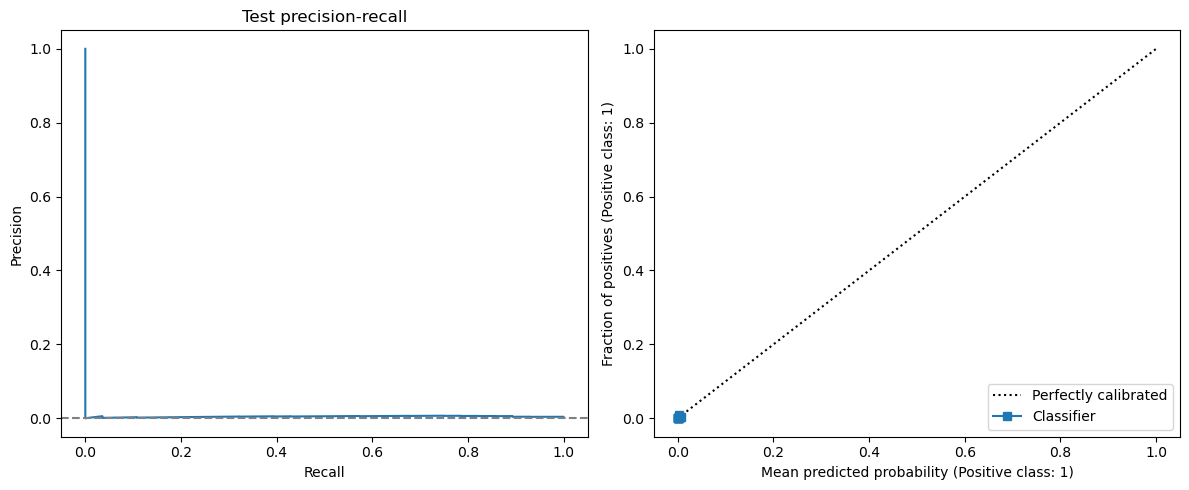

,feature,importance_mean,importance_std
22,num__mean_log_actor_api_prior,0.000987,8.069545e-04
75,cat__last_service_sts.amazonaws.com,0.000706,2.764605e-04
38,num__new_ip_rate_current,0.000406,1.693348e-04
97,cat__last_ua_family_other,0.000281,2.125131e-04
63,cat__last_service_iam.amazonaws.com,0.000198,2.196483e-05
59,cat__last_service_ec2.amazonaws.com,0.000165,4.681118e-05
33,num__prior_active_windows_7d,0.000103,1.522049e-04
18,num__new_actor_ip_count,0.000097,9.495055e-05
27,num__prior_auth_errors_24h,0.000066,3.670263e-05
39,num__hour_sin,0.000063,2.199870e-04


In [13]:
def bootstrap_metric_ci(y,s,metric_fn,iterations=500,seed=SEED):
    y=np.asarray(y); s=np.asarray(s); rng=np.random.default_rng(seed); values=[]; pos=np.flatnonzero(y==1); neg=np.flatnonzero(y==0)
    if not len(pos) or not len(neg): return {'low':np.nan,'median':np.nan,'high':np.nan}
    for _ in range(int(iterations)):
        idx=np.concatenate([rng.choice(pos,len(pos),replace=True),rng.choice(neg,len(neg),replace=True)])
        try: values.append(float(metric_fn(y[idx],s[idx])))
        except Exception: pass
    if not values: return {'low':np.nan,'median':np.nan,'high':np.nan}
    low,med,high=np.quantile(values,[.025,.5,.975]); return {'low':float(low),'median':float(med),'high':float(high)}
BOOTSTRAP_CI={'average_precision':bootstrap_metric_ci(y_test,test_scores,average_precision_score,CFG.bootstrap_iterations),'roc_auc':bootstrap_metric_ci(y_test,test_scores,roc_auc_score,CFG.bootstrap_iterations)}; print('Bootstrap 95% CIs:',json.dumps(BOOTSTRAP_CI,indent=2))
fig,axes=plt.subplots(1,2,figsize=(12,5)); precision,recall,_=precision_recall_curve(y_test,test_scores); axes[0].plot(recall,precision); axes[0].axhline(y_test.mean(),ls='--',color='gray'); axes[0].set(title='Test precision-recall',xlabel='Recall',ylabel='Precision')
try: CalibrationDisplay.from_predictions(y_test,test_scores,n_bins=10,strategy='quantile',ax=axes[1])
except Exception: axes[1].text(.1,.5,'Calibration plot unavailable')
fig.tight_layout(); fig.savefig(OUTPUT_DIR/'test_pr_and_calibration.png',dpi=160,bbox_inches='tight'); plt.show()
rng=np.random.default_rng(SEED); pos=np.flatnonzero(y_test.to_numpy()==1); neg=np.flatnonzero(y_test.to_numpy()==0); remaining=max(0,CFG.permutation_max_rows-len(pos)); chosen=np.concatenate([pos,rng.choice(neg,size=min(len(neg),remaining),replace=False)]); perm=permutation_importance(CALIBRATED_MODEL,Xte[chosen],y_test.iloc[chosen],scoring='average_precision',n_repeats=5,random_state=SEED,n_jobs=-1)
try: final_names=BASE_PREPROCESSOR.get_feature_names_out().astype(str).tolist()
except Exception: final_names=[f'f_{i}' for i in range(Xte.shape[1])]
PERMUTATION_IMPORTANCE=pd.DataFrame({'feature':final_names,'importance_mean':perm.importances_mean,'importance_std':perm.importances_std}).sort_values('importance_mean',ascending=False); display(PERMUTATION_IMPORTANCE.head(25))

## 12. Reproducible exports and inference bundle

In [14]:
CATALOG_RESULTS.to_csv(OUTPUT_DIR/'stage_a_full_classifier_catalog.csv',index=False); pd.DataFrame(CATALOG_FAILURES).to_csv(OUTPUT_DIR/'stage_a_failures.csv',index=False); ADVANCED_RESULTS.to_csv(OUTPUT_DIR/'stage_b_temporal_benchmark.csv',index=False); pd.DataFrame(ADVANCED_FAILURES).to_csv(OUTPUT_DIR/'stage_b_failures.csv',index=False); VALIDATION_RESULTS.to_csv(OUTPUT_DIR/'validation_candidate_ranking.csv',index=False); BUDGET_TABLE.to_csv(OUTPUT_DIR/'validation_alert_budget_thresholds.csv',index=False); TEST_PREDICTIONS.to_csv(OUTPUT_DIR/'test_predictions.csv',index=False); MONTHLY_RESULTS.to_csv(OUTPUT_DIR/'test_monthly_metrics.csv',index=False); ACTOR_NOVELTY_RESULTS.to_csv(OUTPUT_DIR/'test_actor_novelty_metrics.csv',index=False); VOLUME_RESULTS.to_csv(OUTPUT_DIR/'test_volume_metrics.csv',index=False); POLICY_CATEGORY_RESULTS.to_csv(OUTPUT_DIR/'test_policy_category_metrics.csv',index=False); PERMUTATION_IMPORTANCE.to_csv(OUTPUT_DIR/'permutation_importance.csv',index=False); SPLIT_AUDIT.to_csv(OUTPUT_DIR/'split_audit.csv',index=False)
if not OPTUNA_RESULTS.empty: OPTUNA_RESULTS.to_csv(OUTPUT_DIR/'optuna_model_summary.csv',index=False)
for family,study in OPTUNA_STUDIES.items(): study.trials_dataframe().to_csv(OUTPUT_DIR/f'optuna_{family}_history.csv',index=False)
bundle={'preprocessor':BASE_PREPROCESSOR,'model':CALIBRATED_MODEL,'threshold':OPERATING_THRESHOLD,'feature_columns':FEATURE_COLUMNS,'target_column':TARGET_COLUMN,'target_mode':CFG.target_mode,'selected_model':SELECTED_MODEL_NAME,'best_params':best_params_for(SELECTED_MODEL_NAME)}; joblib.dump(bundle,OUTPUT_DIR/'cloudtrail_robust_model.joblib')
METRICS_PACKAGE={'selected_model':SELECTED_MODEL_NAME,'target':TARGET_COLUMN,'threshold':OPERATING_THRESHOLD,'test':TEST_METRICS,'august_2019_stress':AUGUST_2019_RESULTS,'bootstrap_ci':BOOTSTRAP_CI}; (OUTPUT_DIR/'metrics.json').write_text(json.dumps(METRICS_PACKAGE,indent=2,default=str),encoding='utf-8'); (OUTPUT_DIR/'feature_lists.json').write_text(json.dumps({'numeric':BEHAVIOR_NUMERIC,'categorical':BEHAVIOR_CATEGORICAL,'policy_extra':POLICY_AWARE_EXTRA,'used':FEATURE_COLUMNS},indent=2),encoding='utf-8')
def file_sha256(path):
    h=sha256()
    with Path(path).open('rb') as f:
        for block in iter(lambda:f.read(1024*1024),b''): h.update(block)
    return h.hexdigest()
manifest={'created_utc':pd.Timestamp.now(tz='UTC').isoformat(),'config':{**asdict(CFG),'workspace':str(WORKSPACE)},'feature_parquet':str(FEATURE_PARQUET),'feature_sha256':file_sha256(FEATURE_PARQUET),'selected_model':SELECTED_MODEL_NAME,'target':TARGET_COLUMN,'threshold':OPERATING_THRESHOLD,'versions':{'python':platform.python_version(),'sklearn':sklearn.__version__,'duckdb':duckdb.__version__,'lazypredict':getattr(lazypredict,'__version__','unknown'),'optuna':optuna.__version__}}; (OUTPUT_DIR/'run_manifest.json').write_text(json.dumps(manifest,indent=2,default=str),encoding='utf-8')
def predict_engineered_actor_windows(frame,bundle_path=OUTPUT_DIR/'cloudtrail_robust_model.joblib'):
    b=joblib.load(bundle_path); missing=sorted(set(b['feature_columns'])-set(frame.columns))
    if missing: raise KeyError(f'Missing engineered columns: {missing}')
    Xt=np.asarray(b['preprocessor'].transform(frame[b['feature_columns']])); scores=score_vector(b['model'],Xt); return pd.DataFrame({'score':scores,'prediction':(scores>=b['threshold']).astype('int8')},index=frame.index)
reload_scores=predict_engineered_actor_windows(X_test.head(25)); np.testing.assert_allclose(reload_scores.score.to_numpy(),test_scores[:25],rtol=1e-8,atol=1e-10); print('Artifacts written to:',OUTPUT_DIR)

Artifacts written to: E:\Trash\MLOPS\cloudtrail_eda_workspace\robust_ml_outputs


## 13. Final validation checklist and research decision
Do not deploy only because one model ranks first. Obtain analyst-reviewed labels and rerun detection and forecasting modes.

In [15]:
required_artifacts={'cloudtrail_robust_model.joblib','stage_a_full_classifier_catalog.csv','stage_b_temporal_benchmark.csv','validation_candidate_ranking.csv','validation_alert_budget_thresholds.csv','metrics.json','test_predictions.csv','test_monthly_metrics.csv','test_actor_novelty_metrics.csv','test_volume_metrics.csv','run_manifest.json'}
attempted_catalog=set(CATALOG_RESULTS.model)|(set(pd.DataFrame(CATALOG_FAILURES)['model']) if CATALOG_FAILURES else set()); attempted_advanced=set(ADVANCED_RESULTS.model)|(set(pd.DataFrame(ADVANCED_FAILURES)['model']) if ADVANCED_FAILURES else set())
checks={'corrected_feature_parquet_exists':FEATURE_PARQUET.exists(),'only_global_tail_censored':int(FEATURE_AUDIT.loc[0,'incorrectly_censored_windows'])==0,'unique_actor_window_keys':duplicate_keys==0,'chronological_order':SPLITS['train'].window_start.max()<SPLITS['validation'].window_start.min()<SPLITS['test'].window_start.min(),'all_splits_two_class':all(x[TARGET_COLUMN].nunique()==2 for x in SPLITS.values()),'no_banned_features':not violations,'full_catalog_attempted':set(SKLEARN_CATALOG).issubset(attempted_catalog),'advanced_families_attempted':set(ADVANCED_FAMILIES).issubset(attempted_advanced),'finite_test_scores':bool(np.isfinite(test_scores).all()),'artifacts_exist':required_artifacts.issubset({p.name for p in OUTPUT_DIR.iterdir()})}
VALIDATION_REPORT=pd.Series(checks,name='passed'); display(VALIDATION_REPORT.to_frame())
if not VALIDATION_REPORT.all(): raise AssertionError(VALIDATION_REPORT[~VALIDATION_REPORT].index.tolist())
print('✅ Robust pipeline validation passed. Selected model:',SELECTED_MODEL_NAME)

,passed
corrected_feature_parquet_exists,True
only_global_tail_censored,True
unique_actor_window_keys,True
chronological_order,True
all_splits_two_class,True
no_banned_features,True
full_catalog_attempted,True
advanced_families_attempted,True
finite_test_scores,True
artifacts_exist,True


✅ Robust pipeline validation passed. Selected model: LogisticRegression
